# KKBox Churn — Exploratory Data Analysis

Focused EDA on the leakage-safe v2 modeling dataset (`outputs/kkbox_modeling_dataset_v2.csv`, 970,960 rows x 40 columns).

This notebook is read-only against the dataset and does not train any model — it visually confirms and extends the findings from `FEATURE_AUDIT.md`.

Sections:
1. Overall churn distribution
2. Churn rate by categorical / binary features
3. Key numeric feature distributions split by churn
4. Tenure, transaction volume, auto-renewal & cancellation vs churn
5. Missingness patterns
6. Flagged proxy / leakage-adjacent features
7. EDA findings


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titlesize"] = 11
plt.rcParams["axes.titleweight"] = "bold"

COLOR_NO_CHURN = "#4C72B0"
COLOR_CHURN = "#DD8452"


## 0. Load data

`msno` is dropped on load — it's a unique hashed ID with no analytical value here.

In [2]:
DATA_PATH = Path("..") / "outputs" / "kkbox_modeling_dataset_v2.csv"

usecols = [c for c in pd.read_csv(DATA_PATH, nrows=0).columns if c != "msno"]
df = pd.read_csv(DATA_PATH, usecols=usecols)

float_cols = df.select_dtypes("float64").columns
df[float_cols] = df[float_cols].astype("float32")

print(f"Rows: {len(df):,}  |  Columns: {df.shape[1]}")
df.head(3)


Rows: 970,960  |  Columns: 39


,is_churn,city,bd_clean,bd_missing,gender,gender_missing,registered_via,registered_via_missing,registration_init_time,registration_year,...,auto_renew_pct,avg_payment_plan_days,avg_revenue_per_txn,total_discount,discount_rate,membership_expire_date_invalid,txn_span_days,days_since_last_txn,membership_remaining_days,has_transactions_data
0,1,5.0,28.0,0.0,male,0.0,3.0,0.0,20131224.0,2013.0,...,0.833333,10.0,149.000000,-596.0,-2.0,0.0,700.0,0.0,30.0,1
1,1,13.0,20.0,0.0,male,0.0,3.0,0.0,20131224.0,2013.0,...,0.000000,25.4,125.400002,0.0,0.0,0.0,344.0,18.0,12.0,1
2,1,13.0,18.0,0.0,male,0.0,3.0,0.0,20131228.0,2013.0,...,0.000000,30.0,149.000000,0.0,0.0,0.0,530.0,29.0,7.0,1


## 1. Overall churn distribution

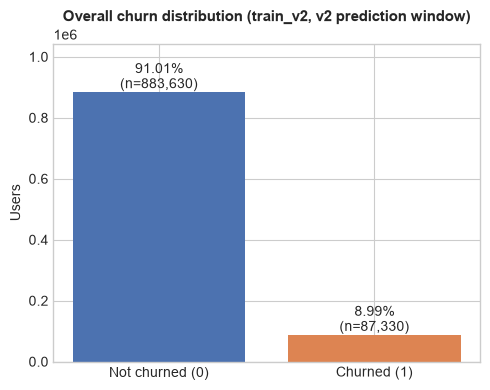

Churn rate: 8.99%  (87,330 / 970,960 users)


In [3]:
churn_counts = df["is_churn"].value_counts().sort_index()
churn_pct = churn_counts / len(df) * 100

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["Not churned (0)", "Churned (1)"], churn_counts.values,
              color=[COLOR_NO_CHURN, COLOR_CHURN])
for bar, pct in zip(bars, churn_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{pct:.2f}%\n(n={int(bar.get_height()):,})",
            ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Users")
ax.set_title("Overall churn distribution (train_v2, v2 prediction window)")
ax.margins(y=0.18)
plt.tight_layout()
plt.show()

print(f"Churn rate: {churn_pct[1]:.2f}%  ({churn_counts[1]:,} / {len(df):,} users)")


## 2. Churn rate by categorical / binary features

Dashed line marks the overall churn rate (8.99%) for reference.

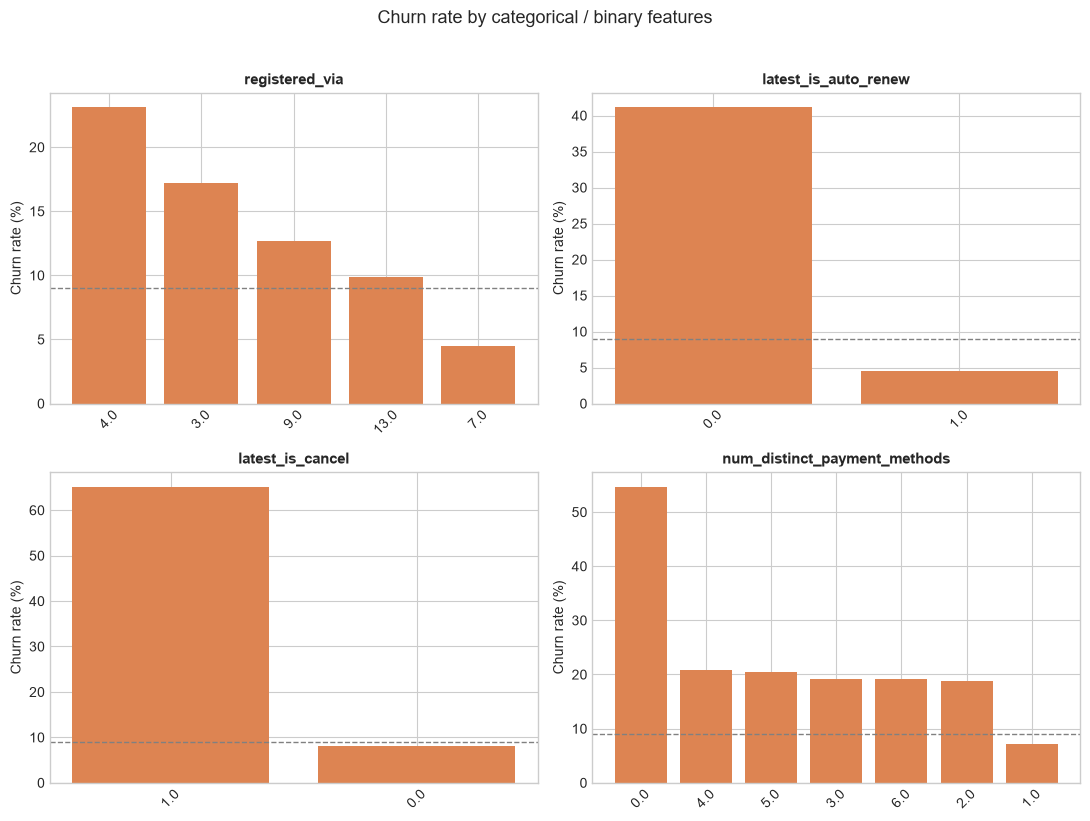

In [4]:
def churn_rate_by(col, ax, min_count=0, dropna=True):
    g = df.groupby(col, dropna=dropna)["is_churn"].agg(["mean", "count"])
    g["mean"] *= 100
    g = g[g["count"] >= min_count].sort_values("mean", ascending=False)
    ax.bar(g.index.astype(str), g["mean"], color=COLOR_CHURN)
    ax.axhline(churn_pct[1], color="grey", linestyle="--", linewidth=1)
    ax.set_ylabel("Churn rate (%)")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=45)
    return g

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
churn_rate_by("registered_via", axes[0, 0])
churn_rate_by("latest_is_auto_renew", axes[0, 1])
churn_rate_by("latest_is_cancel", axes[1, 0])
churn_rate_by("num_distinct_payment_methods", axes[1, 1], min_count=30)
fig.suptitle("Churn rate by categorical / binary features", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


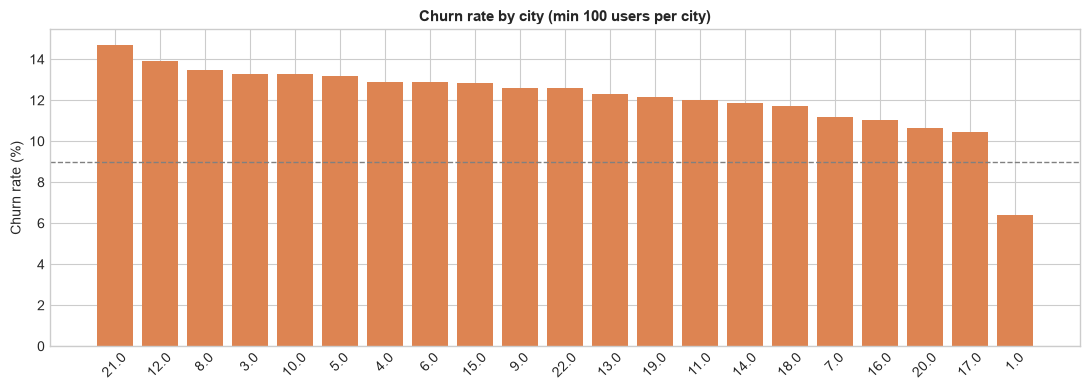

city=1 alone is 45.6% of all users, with a churn rate of 6.41% (well below the 8.99% overall rate).


In [5]:
fig, ax = plt.subplots(figsize=(11, 4))
g = churn_rate_by("city", ax, min_count=100)
ax.set_title("Churn rate by city (min 100 users per city)")
plt.tight_layout()
plt.show()

city1_share = (df["city"] == 1).mean() * 100
city1_rate = df.loc[df["city"] == 1, "is_churn"].mean() * 100
print(f"city=1 alone is {city1_share:.1f}% of all users, with a churn rate of {city1_rate:.2f}% "
      f"(well below the {churn_pct[1]:.2f}% overall rate).")


## 3. Key numeric feature distributions split by churn

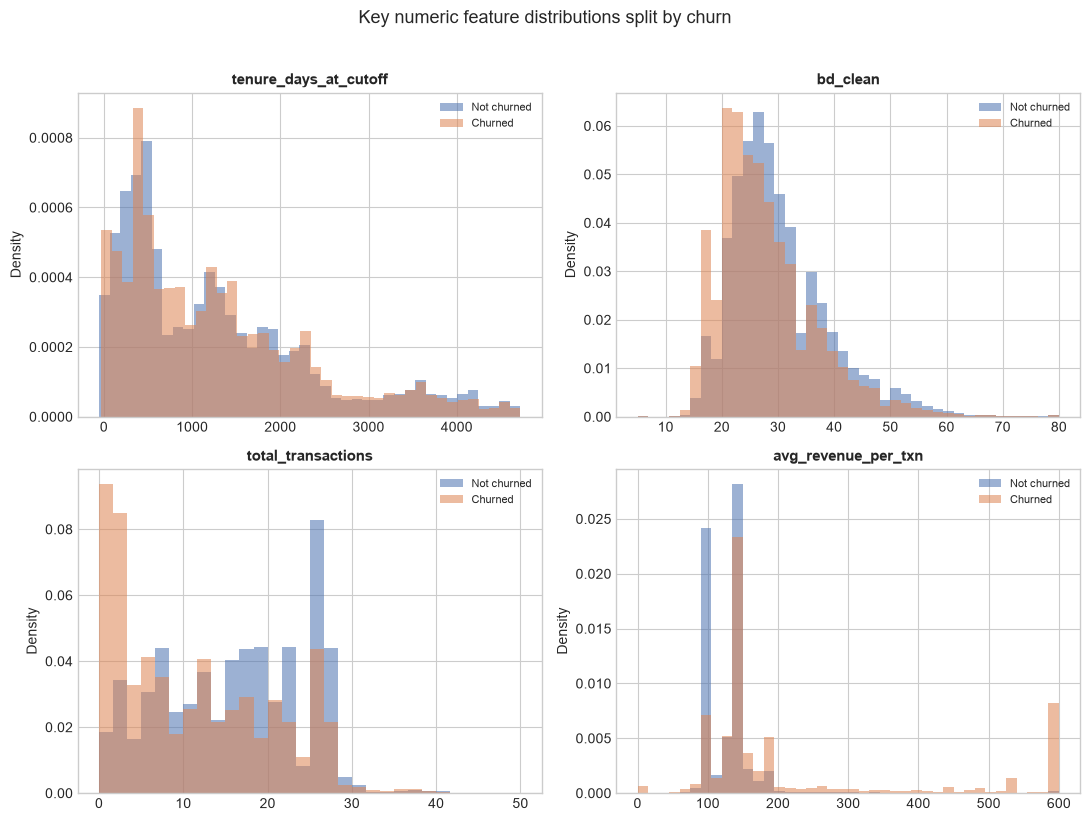

In [6]:
def hist_by_churn(col, ax, bins=40, clip=None):
    d0 = df.loc[df["is_churn"] == 0, col].dropna()
    d1 = df.loc[df["is_churn"] == 1, col].dropna()
    if clip is not None:
        d0, d1 = d0.clip(*clip), d1.clip(*clip)
    ax.hist(d0, bins=bins, density=True, alpha=0.55, color=COLOR_NO_CHURN, label="Not churned")
    ax.hist(d1, bins=bins, density=True, alpha=0.55, color=COLOR_CHURN, label="Churned")
    ax.set_title(col)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
hist_by_churn("tenure_days_at_cutoff", axes[0, 0])
hist_by_churn("bd_clean", axes[0, 1], clip=(5, 80))
hist_by_churn("total_transactions", axes[1, 0], bins=30, clip=(0, 50))
hist_by_churn("avg_revenue_per_txn", axes[1, 1], bins=40, clip=(0, 600))
fig.suptitle("Key numeric feature distributions split by churn", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


## 4. Tenure, transaction volume, auto-renewal & cancellation vs churn

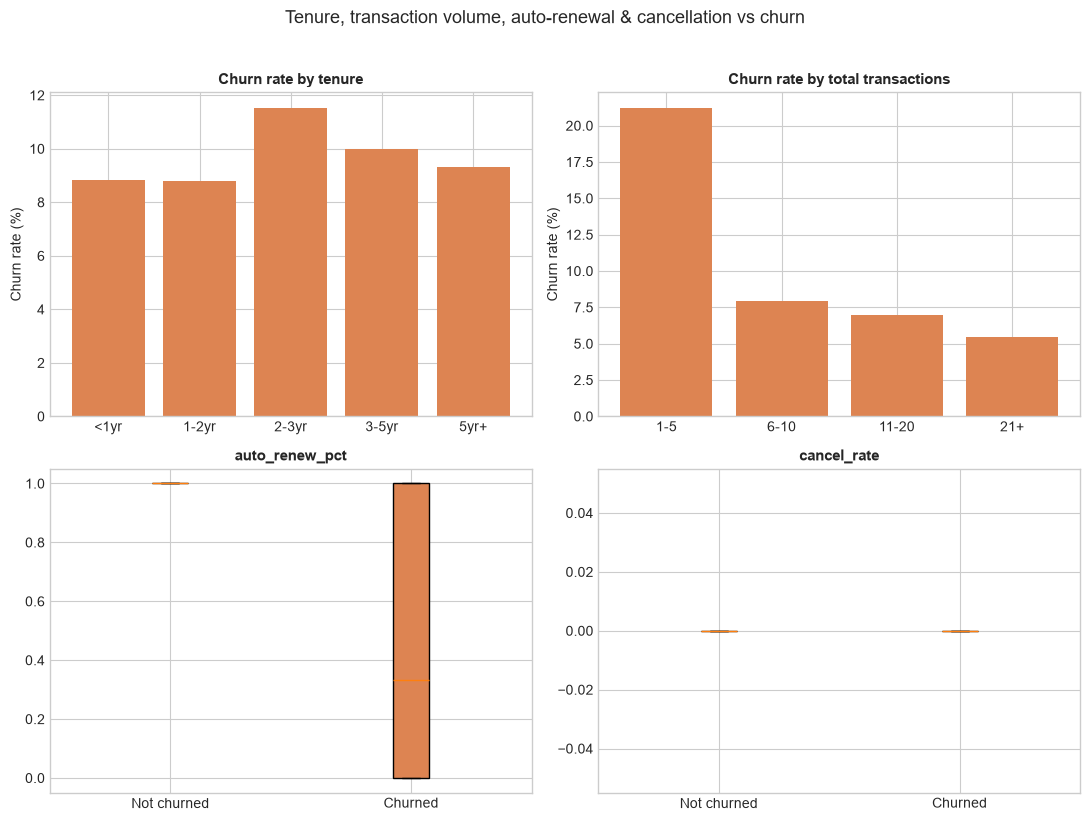

In [7]:
bins_tenure = [-100000, 365, 730, 1095, 1825, 100000]
labels_tenure = ["<1yr", "1-2yr", "2-3yr", "3-5yr", "5yr+"]
df["_tenure_bucket"] = pd.cut(df["tenure_days_at_cutoff"], bins=bins_tenure, labels=labels_tenure)

bins_txn = [-1, 5, 10, 20, 1000]
labels_txn = ["1-5", "6-10", "11-20", "21+"]
df["_txn_bucket"] = pd.cut(df["total_transactions"], bins=bins_txn, labels=labels_txn)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

g = df.groupby("_tenure_bucket", observed=True)["is_churn"].mean() * 100
axes[0, 0].bar(g.index.astype(str), g.values, color=COLOR_CHURN)
axes[0, 0].set_title("Churn rate by tenure")
axes[0, 0].set_ylabel("Churn rate (%)")

g = df.groupby("_txn_bucket", observed=True)["is_churn"].mean() * 100
axes[0, 1].bar(g.index.astype(str), g.values, color=COLOR_CHURN)
axes[0, 1].set_title("Churn rate by total transactions")
axes[0, 1].set_ylabel("Churn rate (%)")

for ax, col in zip([axes[1, 0], axes[1, 1]], ["auto_renew_pct", "cancel_rate"]):
    data = [df.loc[df["is_churn"] == 0, col].dropna(), df.loc[df["is_churn"] == 1, col].dropna()]
    bp = ax.boxplot(data, tick_labels=["Not churned", "Churned"], patch_artist=True, showfliers=False)
    for patch, color in zip(bp["boxes"], [COLOR_NO_CHURN, COLOR_CHURN]):
        patch.set_facecolor(color)
    ax.set_title(col)

fig.suptitle("Tenure, transaction volume, auto-renewal & cancellation vs churn", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


### Payment-behaviour confound check

`FEATURE_AUDIT.md` flagged that `latest_payment_plan_days` is *positively* correlated with churn
- **The "longer final plan → higher churn" pattern is confounded by auto-renew, and localized to one segment**: churned users with auto-renew=1 have a plan-length distribution identical to non-churners (median ~30 days), while churned users with auto-renew=0 show a much wider, right-skewed distribution (IQR roughly 30-195 days). The raw correlation is driven entirely by this non-renewing subgroup, not by long-plan users generally being more likely to leave.
auto-renewal status. Splitting by both variables at once tests that directly.

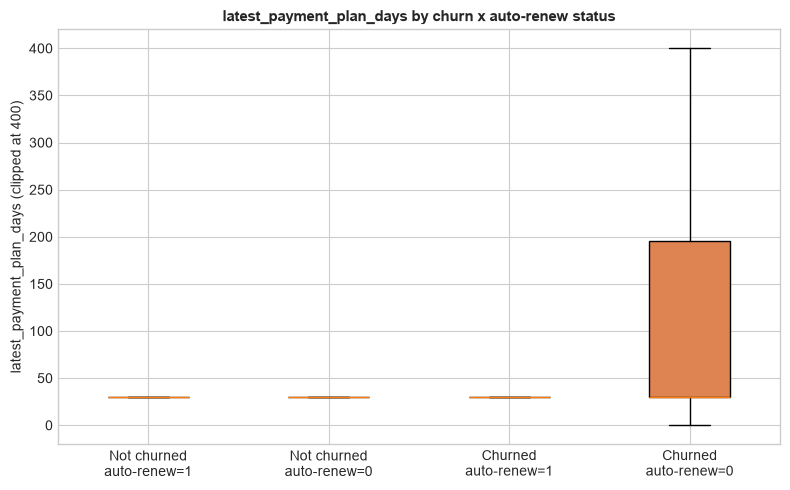

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
groups, labels, colors = [], [], []
for churn_val, churn_label, color in [(0, "Not churned", COLOR_NO_CHURN), (1, "Churned", COLOR_CHURN)]:
    for ar_val, ar_label in [(1, "auto-renew=1"), (0, "auto-renew=0")]:
        mask = (df["is_churn"] == churn_val) & (df["latest_is_auto_renew"] == ar_val)
        groups.append(df.loc[mask, "latest_payment_plan_days"].clip(0, 400).dropna())
        labels.append(f"{churn_label}\n{ar_label}")
        colors.append(color)

bp = ax.boxplot(groups, tick_labels=labels, patch_artist=True, showfliers=False)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
ax.set_ylabel("latest_payment_plan_days (clipped at 400)")
ax.set_title("latest_payment_plan_days by churn x auto-renew status")
plt.tight_layout()
plt.show()


## 5. Missingness patterns

Missingness is structurally clustered into two blocks: members-derived columns (green, ~11.3% missing together) and transaction-derived columns (purple, ~0.26-0.30% missing together).

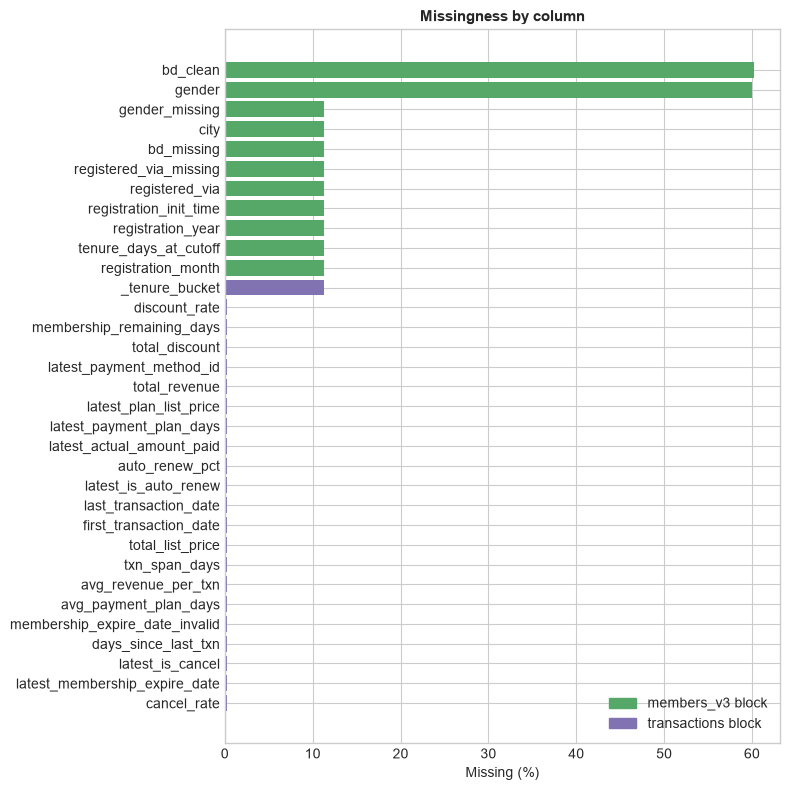

In [9]:
MEMBERS_BLOCK = {
    "city", "bd_clean", "bd_missing", "gender", "gender_missing", "registered_via",
    "registered_via_missing", "registration_init_time", "registration_year",
    "registration_month", "tenure_days_at_cutoff",
}

missing_pct = df.isna().mean().sort_values(ascending=False) * 100
missing_pct = missing_pct[missing_pct > 0]
colors = ["#55A868" if c in MEMBERS_BLOCK else "#8172B2" for c in missing_pct.index]

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(missing_pct.index[::-1], missing_pct.values[::-1], color=colors[::-1])
ax.set_xlabel("Missing (%)")
ax.set_title("Missingness by column")

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#55A868", label="members_v3 block"),
                    Patch(color="#8172B2", label="transactions block")],
          loc="lower right")
plt.tight_layout()
plt.show()


## 6. Flagged proxy / leakage-adjacent features

No feature here uses post-cutoff data (the pipeline's own leakage guard already verified that).
But `membership_remaining_days`, `days_since_last_txn`, and `latest_is_cancel` are mechanically
close to the WSDM churn label's own construction (*"churned = no renewal within 30 days of
membership expiry"*), so they behave less like independent behavioral signals and more like
partial restatements of the label itself. See `FEATURE_AUDIT.md` §4 for the full discussion.

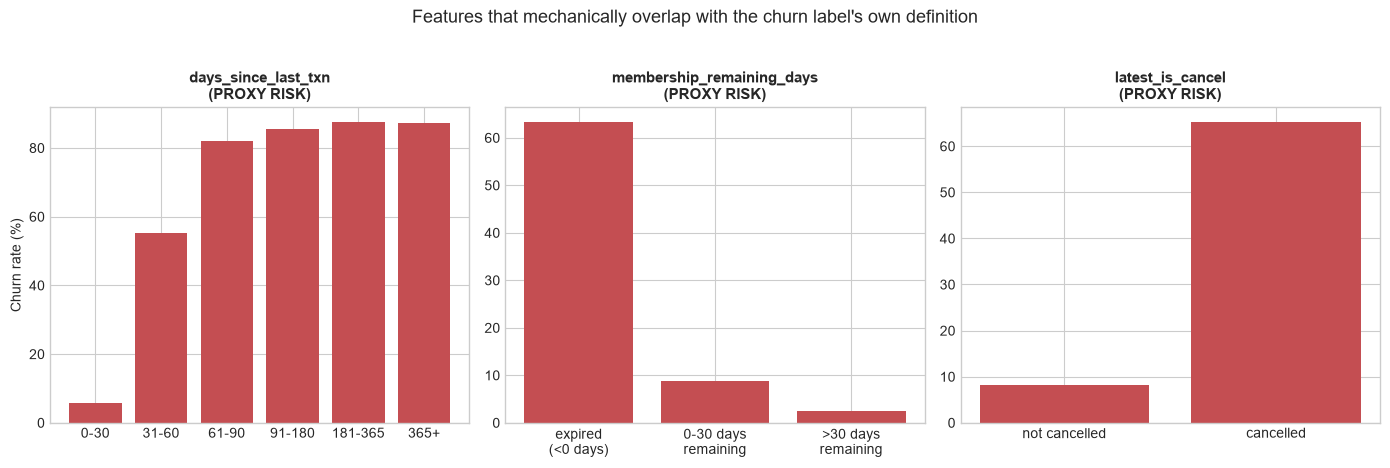

In [10]:
bins_dslt = [-1, 30, 60, 90, 180, 365, 100000]
labels_dslt = ["0-30", "31-60", "61-90", "91-180", "181-365", "365+"]
df["_dslt_bucket"] = pd.cut(df["days_since_last_txn"], bins=bins_dslt, labels=labels_dslt)

bins_mrd = [-100000, -1, 30, 100000]
labels_mrd = ["expired\n(<0 days)", "0-30 days\nremaining", ">30 days\nremaining"]
df["_mrd_bucket"] = pd.cut(df["membership_remaining_days"], bins=bins_mrd, labels=labels_mrd)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

g = df.groupby("_dslt_bucket", observed=True)["is_churn"].mean() * 100
axes[0].bar(g.index.astype(str), g.values, color="#C44E52")
axes[0].set_title("days_since_last_txn\n(PROXY RISK)")
axes[0].set_ylabel("Churn rate (%)")

g = df.groupby("_mrd_bucket", observed=True)["is_churn"].mean() * 100
axes[1].bar(g.index.astype(str), g.values, color="#C44E52")
axes[1].set_title("membership_remaining_days\n(PROXY RISK)")

g = df.groupby("latest_is_cancel", observed=True)["is_churn"].mean() * 100
axes[2].bar(["not cancelled", "cancelled"], g.values, color="#C44E52")
axes[2].set_title("latest_is_cancel\n(PROXY RISK)")

fig.suptitle("Features that mechanically overlap with the churn label's own definition", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()


## 7. EDA findings

- **Churn rate is 8.99%** (87,330 / 970,960) — a realistic, imbalanced subscription churn rate; any downstream model needs class-imbalance handling (weighting, PR-AUC, stratified CV) rather than plain accuracy.
- **Recency is an almost step-function predictor.** Churn rate is 5.8% for users active in the last 30 days but jumps to 55%+ within the very next bucket (31-60 days) and keeps climbing toward ~87% beyond 90 days. This mirrors the WSDM label's own 30-day renewal-gap rule — see §6.
- **`membership_remaining_days` behaves the same way**: 2.55% churn when >30 days remain, 8.83% in the 0-30 day window, and 63.24% once membership has already expired at the cutoff. Also flagged as a label proxy, not an independent signal.
- **Auto-renewal is the strongest *legitimately* behavioral driver found**: 4.6% churn with auto-renew on vs 41.1% with it off — an ~9x gap, and unlike the two features above it reflects a standing user preference rather than the outcome itself.
- **Cancellation history matters**: a last transaction flagged `is_cancel=1` carries a 65.2% churn rate vs 8.1% otherwise — intuitive, but close enough to the churn event to be treated cautiously (§6).
- **The "longer final plan → higher churn" pattern is confounded by auto-renew, and localized to one segment**: churned users with auto-renew=1 have a plan-length distribution identical to non-churners (median ~30 days), while churned users with auto-renew=0 show a much wider, right-skewed distribution (IQR roughly 30-195 days). The raw correlation is driven entirely by this non-renewing subgroup, not by long-plan users generally being more likely to leave.
- **`registered_via` shows real spread**: registration method 4 churns at 23.1% vs method 7 at just 4.5% (method 7 also dominates volume, ~47.6% of users). `registered_via` is a **registration-channel proxy only** -- KKBox's raw sign-up method code, not verified acquisition-channel, campaign, or advertising data (no spend, CAC, or attribution exists anywhere in this dataset) -- so this describes a real difference in churn by *how users registered*, not a claim about acquisition-channel quality or marketing efficiency.
- **`city=1` dominates volume (45.6% of users) but churns well below average** (6.4% vs 8.99% overall) — worth remembering that "city" mixes in a very large, low-churn segment that could mask smaller cities' patterns if not modeled carefully (one-hot/target encoding rather than treating it as ordinal).
- **Demographics carry only weak signal**: age and tenure distributions overlap heavily between churned and retained users — consistent with the near-zero correlations reported in `FEATURE_AUDIT.md`.
- **Missingness is fully structural, not random**: exactly 11.33% of users are missing every members-derived column together (no `members_v3` record), and ~0.26-0.30% are missing every transaction-derived column together (no transaction at/before cutoff). Imputation should be designed per block, e.g. an explicit "no member record" / "no transaction record" pathway, not per-column mean/median filling.

**No models were trained and the modeling dataset was not modified in this notebook.**
